In [1]:
import numpy as np
import time
import random
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. BCOP Problem Definition (Mobile Edge Context)
# ==========================================
class BCOPProblem:
    def __init__(self, validators):
        self.validators = np.array(validators)
        self.m_max = len(validators)
        # Dynamic dimension: length of validators + 1 for block size
        self.dim = self.m_max + 1 
        
        self.minVal, self.maxVal = 5, self.m_max # maxVal is now dynamic
        self.minTrans, self.maxTrans = 50, 500
        self.theta, self.q = 1, 4
        self.K, self.B = 100, 0.5
        self.downlink, self.uplink = 1.2, 1.3
        self.xai, self.O = 0.001, 0.5
        
        self.maxSec = self.security(self.maxVal)
        self.minSec = self.security(self.minVal)
        self.maxCost = self.cost(self.validators, self.minTrans)
        minValidators = np.partition(self.validators, self.minVal)[:self.minVal]
        self.minCost = self.cost(minValidators, self.maxTrans)
        self.maxLatency = self.latency(self.maxTrans, self.maxVal, self.validators)
        top5_validators = np.partition(self.validators, -self.minVal)[-self.minVal:]
        self.minLatency = self.latency(self.minTrans, self.minVal, top5_validators)
        self.eval_cache = {}

    def clear_caches(self):
        self.eval_cache.clear()

    def security(self, m):
        return self.theta * (m ** self.q)

    def cost(self, validator_arr, n):
        return (np.sum(validator_arr)) / n

    def latency(self, n, m, validator_arr):
        minX = np.min(validator_arr)
        downlinkDelay = (n * self.B) / self.downlink
        maxCompDelay = self.K / minX
        consensusOverhead = self.xai * (n * self.B) * m
        uplinkFbDelay = self.O / self.uplink
        return downlinkDelay + maxCompDelay + consensusOverhead + uplinkFbDelay

    def evaluate(self, continuous_vector):
        m, n, sel_vals = self.decode_and_repair(continuous_vector)
        key = (m, n, tuple(sel_vals))
        
        if key in self.eval_cache:
            return self.eval_cache[key]
            
        actualLatency = self.latency(n, m, sel_vals)
        actualCost = self.cost(sel_vals, n)
        actualSecurity = self.security(m)
        
        Lnorm = (np.log10(actualLatency) - np.log10(self.minLatency)) / (np.log10(self.maxLatency) - np.log10(self.minLatency))
        Cnorm = (np.log10(actualCost) - np.log10(self.minCost)) / (np.log10(self.maxCost) - np.log10(self.minCost))
        Snorm = (np.log10(actualSecurity) - np.log10(self.minSec)) / (np.log10(self.maxSec) - np.log10(self.minSec))
        Snorm = 1 - Snorm 
        
        utility = (0.333 * Lnorm) + (0.333 * Cnorm) + (0.333 * Snorm)
        fitness = -utility 
        
        self.eval_cache[key] = fitness
        return fitness
    
    def decode_and_repair(self, continuous_vector):
        # Use self.m_max instead of hard-coded 25
        val_probs = continuous_vector[:self.m_max]
        val_bits = (val_probs > 0.5).astype(int)
        m = np.sum(val_bits)
        
        if m < self.minVal:
            zero_indices = np.where(val_bits == 0)[0]
            flip_indices = np.random.choice(zero_indices, size=(self.minVal - int(m)), replace=False)
            val_bits[flip_indices] = 1
            m = self.minVal
            
        sel_vals = self.validators[val_bits == 1]
        # n is at the last index (self.m_max)[cite: 1]
        n = int(round(continuous_vector[self.m_max]))
        n = np.clip(n, self.minTrans, self.maxTrans)
        
        return int(m), int(n), sel_vals

In [3]:
# ==========================================
# Binary Coded GA
# ==========================================
class BCGA:
    def __init__(self, problem, pop_size=150, gens=150):
        self.p = problem
        self.POP = pop_size
        self.GEN = gens
        self.chrom_length = self.p.m_max + 9 
        
    def decode(self, chrom):
        val_bits = chrom[:self.p.m_max] 
        n_decimal = int("".join(str(int(b)) for b in chrom[self.p.m_max:]), 2) 
        n = 50 + n_decimal
        vec = np.zeros(self.p.dim)
        vec[:self.p.m_max] = val_bits 
        vec[self.p.m_max] = n 
        return vec
        
    def run(self):
        self.p.clear_caches() 
        pop = np.random.randint(0, 2, (self.POP, self.chrom_length)) 
        best_fit = -float('inf')
        best_sol = None
        history = []
        
        for t in range(self.GEN): 
            fits = np.array([self.p.evaluate(self.decode(x)) for x in pop]) 
            sort_idx = np.argsort(fits)[::-1] 
            
            if fits[sort_idx[0]] > best_fit: 
                best_fit = fits[sort_idx[0]] 
                best_sol = pop[sort_idx[0]].copy()
                
            elites = pop[sort_idx[:max(2, int(0.05 * self.POP))]].copy() 
            new_pop = list(elites)
            
            def tournament_select():
                idx = np.random.choice(self.POP, 3, replace=False)
                return pop[idx[np.argmax(fits[idx])]]

            mut_prob = 1.0 / self.chrom_length
            
            while len(new_pop) < self.POP: 
                p1, p2 = tournament_select(), tournament_select()
                if random.random() < 0.8: 
                    pt = np.random.randint(1, self.chrom_length - 1) 
                    c1 = np.concatenate([p1[:pt], p2[pt:]]) 
                    c2 = np.concatenate([p2[:pt], p1[pt:]]) 
                else: 
                    c1, c2 = p1.copy(), p2.copy() 
                    
                for c in [c1, c2]:
                    if len(new_pop) < self.POP:
                        if random.random() < 0.15: 
                            mut_pts = np.random.rand(self.chrom_length) < mut_prob 
                            c[mut_pts] ^= 1 
                        new_pop.append(c) 
                    
            pop = np.array(new_pop)
            history.append(-best_fit) 
            
        m, n, _ = self.p.decode_and_repair(self.decode(best_sol))
        return -best_fit, history, m, n 

In [4]:
# ==========================================
# 1. Base Continuous Optimizer
# ==========================================
class ContinuousOptimizer:
    def __init__(self, problem, pop_size=150, gens=150):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens
        self.dim = problem.dim
        # Dynamic boundaries based on actual validator count
        self.bounds_min = np.array([0.0] * self.prob.m_max + [50.0])
        self.bounds_max = np.array([1.0] * self.prob.m_max + [500.0])

    def init_population(self):
        pop = np.zeros((self.pop_size, self.dim))
        pop[:, :self.prob.m_max] = np.random.uniform(0.0, 1.0, (self.pop_size, self.prob.m_max))
        pop[:, self.prob.m_max] = np.random.uniform(50.0, 500.0, self.pop_size)
        return pop

In [5]:
# ==========================================
# Real Coded GA[cite: 1]
# ==========================================
class RCGA(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        best_fit = -float('inf')
        best_sol = None
        history = []

        for t in range(self.gens):
            fits = np.array([self.prob.evaluate(x) for x in pop])
            sorted_idx = np.argsort(fits)[::-1]
            
            if fits[sorted_idx[0]] > best_fit:
                best_fit = fits[sorted_idx[0]]
                best_sol = pop[sorted_idx[0]].copy()
            
            elites_count = max(2, int(0.05 * self.pop_size))
            elites = pop[sorted_idx[:elites_count]].copy()
            new_pop = list(elites)
            
            def tournament_select():
                idx = np.random.choice(self.pop_size, 3, replace=False)
                return pop[idx[np.argmax(fits[idx])]]

            mut_prob = 1.0 / self.dim 
            
            while len(new_pop) < self.pop_size:
                p1, p2 = tournament_select(), tournament_select()
                alpha = np.random.rand(self.dim)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = (1 - alpha) * p1 + alpha * p2
                
                for child in [c1, c2]:
                    if len(new_pop) < self.pop_size:
                        if random.random() < 0.20:
                            mask = np.random.rand(self.dim) < mut_prob
                            noise = np.random.normal(0, 0.05 * (self.bounds_max - self.bounds_min))
                            child = np.where(mask, child + noise, child)
                            child = np.clip(child, self.bounds_min, self.bounds_max)
                        new_pop.append(child)

            pop = np.array(new_pop)
            history.append(-best_fit) 
            
        m, n, _ = self.prob.decode_and_repair(best_sol)
        return -best_fit, history, m, n

In [6]:
# ==========================================
# PSO[cite: 1]
# ==========================================
class PSO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        w_max, w_min = 0.9, 0.4
        c1, c2 = 1.49618, 1.49618 
        
        pos = self.init_population()
        vel = np.zeros((self.pop_size, self.dim))
        
        pbest_pos = pos.copy()
        pbest_fit = np.array([self.prob.evaluate(p) for p in pos])
        
        gbest_idx = np.argmax(pbest_fit)
        gbest_fit = pbest_fit[gbest_idx]
        gbest_pos = pbest_pos[gbest_idx].copy()
        history = []
        
        for gen in range(self.gens):
            w = w_max - (gen / self.gens) * (w_max - w_min)
            for i in range(self.pop_size):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)
                vel[i] = w * vel[i] + c1 * r1 * (pbest_pos[i] - pos[i]) + c2 * r2 * (gbest_pos - pos[i])
                pos[i] = np.clip(pos[i] + vel[i], self.bounds_min, self.bounds_max)
                
                curr_fit = self.prob.evaluate(pos[i])
                if curr_fit > pbest_fit[i]:
                    pbest_fit[i], pbest_pos[i] = curr_fit, pos[i].copy()
                    if curr_fit > gbest_fit:
                        gbest_fit, gbest_pos = curr_fit, pos[i].copy()
            history.append(-gbest_fit)
                        
        m, n, _ = self.prob.decode_and_repair(gbest_pos)
        return -gbest_fit, history, m, n

In [7]:
# ==========================================
# TLBO[cite: 1]
# ==========================================
class TLBO(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        history = []
        
        best_idx = np.argmax(fits)
        best_fit = fits[best_idx]
        best_sol = pop[best_idx].copy()
        
        for gen in range(self.gens):
            teacher_idx = np.argmax(fits)
            teacher = pop[teacher_idx]
            mean_v = np.mean(pop, axis=0)
            
            # Teaching Phase
            for i in range(self.pop_size):
                tf = np.random.randint(1, 3) 
                new_sol = np.clip(pop[i] + np.random.rand(self.dim) * (teacher - tf * mean_v), self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
            
            # Learning Phase
            for i in range(self.pop_size):
                partner = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                diff = pop[i] - pop[partner] if fits[i] > fits[partner] else pop[partner] - pop[i]
                new_sol = np.clip(pop[i] + np.random.rand(self.dim) * diff, self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i] = new_sol, new_fit
                    
            curr_best_idx = np.argmax(fits)
            if fits[curr_best_idx] > best_fit:
                best_fit = fits[curr_best_idx]
                best_sol = pop[curr_best_idx].copy()
            history.append(-best_fit)
            
        m, n, _ = self.prob.decode_and_repair(best_sol)
        return -best_fit, history, m, n

In [8]:
# ==========================================
# Differential Evolution[cite: 1]
# ==========================================
class DE(ContinuousOptimizer):
    def run(self):
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        history = []
        
        best_idx = np.argmax(fits)
        best_fit = fits[best_idx]
        best_sol = pop[best_idx].copy()
        
        for gen in range(self.gens):
            for i in range(self.pop_size):
                F = np.clip(np.random.normal(0.5, 0.3), 0.1, 1.0)
                CR = np.clip(np.random.normal(0.9, 0.1), 0.1, 1.0)
                
                best_vec = pop[np.argmax(fits)]
                r1, r2 = pop[np.random.choice(self.pop_size, 2, replace=False)]
                mutant = np.clip(best_vec + F * (r1 - r2), self.bounds_min, self.bounds_max)
                
                cross_mask = np.random.rand(self.dim) < CR
                trial = np.where(cross_mask, mutant, pop[i])
                
                trial_fit = self.prob.evaluate(trial)
                if trial_fit > fits[i]:
                    pop[i], fits[i] = trial, trial_fit
                    
            curr_best_idx = np.argmax(fits)
            if fits[curr_best_idx] > best_fit:
                best_fit = fits[curr_best_idx]
                best_sol = pop[curr_best_idx].copy()
            history.append(-best_fit)
                    
        m, n, _ = self.prob.decode_and_repair(best_sol)
        return -best_fit, history, m, n

In [9]:
# ==========================================
# Artificial Bee Colony[cite: 1]
# ==========================================
class ABC(ContinuousOptimizer):
    def run(self, limit=50): 
        self.prob.clear_caches()
        pop = self.init_population()
        fits = np.array([self.prob.evaluate(p) for p in pop])
        trials = np.zeros(self.pop_size)
        history = []
        
        best_idx = np.argmax(fits)
        best_fit = fits[best_idx]
        best_sol = pop[best_idx].copy()

        for gen in range(self.gens):
            for i in range(self.pop_size):
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                phi = np.random.uniform(-1, 1, self.dim)
                new_sol = np.clip(pop[i] + phi * (pop[i] - pop[k]), self.bounds_min, self.bounds_max)
                
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            prob_dist = (fits - np.min(fits)) / (np.sum(fits - np.min(fits)) + 1e-9)
            for _ in range(self.pop_size):
                i = np.random.choice(self.pop_size, p=prob_dist)
                k = np.random.choice([idx for idx in range(self.pop_size) if idx != i])
                new_sol = np.clip(pop[i] + np.random.uniform(-1, 1, self.dim) * (pop[i] - pop[k]), self.bounds_min, self.bounds_max)
                new_fit = self.prob.evaluate(new_sol)
                if new_fit > fits[i]:
                    pop[i], fits[i], trials[i] = new_sol, new_fit, 0
                else:
                    trials[i] += 1

            for i in range(self.pop_size):
                if trials[i] > limit:
                    pop[i, :self.prob.m_max] = np.random.uniform(0.0, 1.0, self.prob.m_max)
                    pop[i, self.prob.m_max] = np.random.uniform(50.0, 500.0)
                    fits[i] = self.prob.evaluate(pop[i])
                    trials[i] = 0

            curr_best_idx = np.argmax(fits)
            if fits[curr_best_idx] > best_fit:
                best_fit = fits[curr_best_idx]
                best_sol = pop[curr_best_idx].copy()
            history.append(-best_fit)
                
        m, n, _ = self.prob.decode_and_repair(best_sol)
        return -best_fit, history, m, n


In [10]:
# ==========================================
# ACO[cite: 1]
# ==========================================
class ACO:
    def __init__(self, problem, pop_size=100, gens=150):
        self.prob = problem
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        self.prob.clear_caches()
        m_max = self.prob.m_max
        
        eta_val = np.ones((m_max, 2))
        eta_val[:, 1] = self.prob.validators / np.max(self.prob.validators)  
        eta_val[:, 0] = 1.0 - eta_val[:, 1]
        eta_trans = np.linspace(500, 50, 451) / 500.0 
        
        tau_val = np.ones((m_max, 2))
        tau_trans = np.ones(451)
        
        best_fit = -float('inf')
        best_sol = None
        history = []

        for gen in range(self.gens):
            pop_sols = []
            pop_fits = []
            
            for _ in range(self.pop_size):
                sol_vals = np.zeros(m_max)
                for i in range(m_max):
                    p = (tau_val[i] ** 1.0) * (eta_val[i] ** 2.5)
                    sol_vals[i] = np.random.choice([0, 1], p=p/p.sum())
                    
                p_t = (tau_trans ** 1.0) * (eta_trans ** 2.5)
                sol_trans_idx = np.random.choice(451, p=p_t/p_t.sum())
                
                vec = np.zeros(m_max + 1)
                vec[:m_max] = sol_vals
                vec[m_max] = 50 + sol_trans_idx
                
                fit = self.prob.evaluate(vec)
                pop_sols.append((sol_vals, sol_trans_idx))
                pop_fits.append(fit)
                
                if fit > best_fit: 
                    best_fit = fit
                    best_sol = vec.copy()
                    
            tau_val *= 0.85
            tau_trans *= 0.85
            
            top_indices = np.argsort(pop_fits)[::-1][:max(2, int(0.20 * self.pop_size))]
            for idx in top_indices:
                reward = 1.0 / (1.0 + (best_fit - pop_fits[idx])) 
                v, t = pop_sols[idx]
                for i in range(m_max): 
                    tau_val[i, int(v[i])] += reward
                tau_trans[int(t)] += reward

            history.append(-best_fit)

        m, n, _ = self.prob.decode_and_repair(best_sol)
        return -best_fit, history, m, n

In [11]:
def plot_grouped_bars(x_labels, data_dict, title, ylabel, is_fitness=True):
    n_groups = len(x_labels)
    n_algos = len(data_dict)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    index = np.arange(n_groups)
    bar_width = 0.10
    opacity = 0.85
    
    colors = plt.cm.get_cmap('tab10', n_algos).colors
    
    for i, (algo_name, values) in enumerate(data_dict.items()):
        bars = ax.bar(index + i * bar_width, values, bar_width, 
                      alpha=opacity, label=algo_name, color=colors[i], edgecolor='black', linewidth=0.5)
        
        for bar in bars:
            height = bar.get_height()
            offset = height * 0.015
            
            # Formats label: 4 decimals for Utility, 2 decimals + "s" for time
            ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{height:.4f}' if is_fitness else f'{height:.2f}s',
                    ha='center', va='bottom', rotation='vertical', 
                    fontsize=9, fontweight='bold', color='black')

    ax.set_xlabel('Problem Instance', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=30)
    
    ax.set_xticks(index + bar_width * (n_algos - 1) / 2)
    ax.set_xticklabels(x_labels)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Algorithms", frameon=True)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.25) 
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [20]:
# ==========================================
# Modified Execution Logic[cite: 1]
# ==========================================
def run_bcop_experiment(validators_array, num_runs=10):
    prob = BCOPProblem(validators_array)
    
    algo_factories = {
        "Binary Coded GA": lambda: BCGA(prob, pop_size=100, gens=100),
        "Real Coded GA": lambda: RCGA(prob, pop_size=100, gens=100),
        "PSO": lambda: PSO(prob, pop_size=100, gens=100),
        "TLBO": lambda: TLBO(prob, pop_size=100, gens=100),
        "Differential Evolution": lambda: DE(prob, pop_size=100, gens=100),
        "Ant Colony Opt (ACO)": lambda: ACO(prob, pop_size=50, gens=100),
        "Artificial Bee Colony": lambda: ABC(prob, pop_size=100, gens=100)
    }

    results_avg_utility = {name: [] for name in algo_factories.keys()}
    results_time = {name: [] for name in algo_factories.keys()}

    print(f"--- Running BCOP Optimization Experiment ({num_runs} Iterations) ---\n")
    
    for name, create_algo in algo_factories.items():
        total_utility = 0
        total_time = 0
        overall_best_u = float('inf') 
        
        for i in range(num_runs):
            algo = create_algo()
            start = time.perf_counter()
            best_u, _, m, n = algo.run()
            end = time.perf_counter()
            
            # Print extraction data for the 1st run only
            if i == 0:
                print(f"[{name} - Run 1 Details] "
                      f"Validators Selected: {m} | "
                      f"Transactions: {n} | "
                      f"Utility: {best_u:.4f}")
            
            total_utility += best_u
            total_time += (end - start)
            
            if best_u < overall_best_u:
                overall_best_u = best_u
                
        avg_utility = total_utility / num_runs
        avg_time = total_time / num_runs
        
        results_avg_utility[name].append(avg_utility)
        results_time[name].append(avg_time)
        
        print(f"[{name} - Overall] Avg Utility: {avg_utility:.4f} | Best Utility: {overall_best_u:.4f} | Avg Time: {avg_time:.2f}s\n")
        
    labels = ["BCOP Instance"]
    plot_grouped_bars(labels, results_avg_utility, "Average Utility Comparison", "Utility U (Lower is Better)", is_fitness=True)
    plot_grouped_bars(labels, results_time, "Algorithm Execution Time Comparison", "Average Time (Seconds)", is_fitness=False)

--- Running BCOP Optimization Experiment (10 Iterations) ---

[Binary Coded GA - Run 1 Details] Validators Selected: 25 | Transactions: 50 | Utility: 0.3393
[Binary Coded GA - Overall] Avg Utility: 0.3393 | Best Utility: 0.3393 | Avg Time: 0.59s

[Real Coded GA - Run 1 Details] Validators Selected: 24 | Transactions: 50 | Utility: 0.3456
[Real Coded GA - Overall] Avg Utility: 0.3462 | Best Utility: 0.3393 | Avg Time: 0.57s

[PSO - Run 1 Details] Validators Selected: 22 | Transactions: 50 | Utility: 0.3544
[PSO - Overall] Avg Utility: 0.3486 | Best Utility: 0.3393 | Avg Time: 0.45s

[TLBO - Run 1 Details] Validators Selected: 25 | Transactions: 50 | Utility: 0.3393
[TLBO - Overall] Avg Utility: 0.3393 | Best Utility: 0.3393 | Avg Time: 1.14s

[Differential Evolution - Run 1 Details] Validators Selected: 24 | Transactions: 50 | Utility: 0.3438
[Differential Evolution - Overall] Avg Utility: 0.3491 | Best Utility: 0.3393 | Avg Time: 0.77s

[Ant Colony Opt (ACO) - Run 1 Details] Validators

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


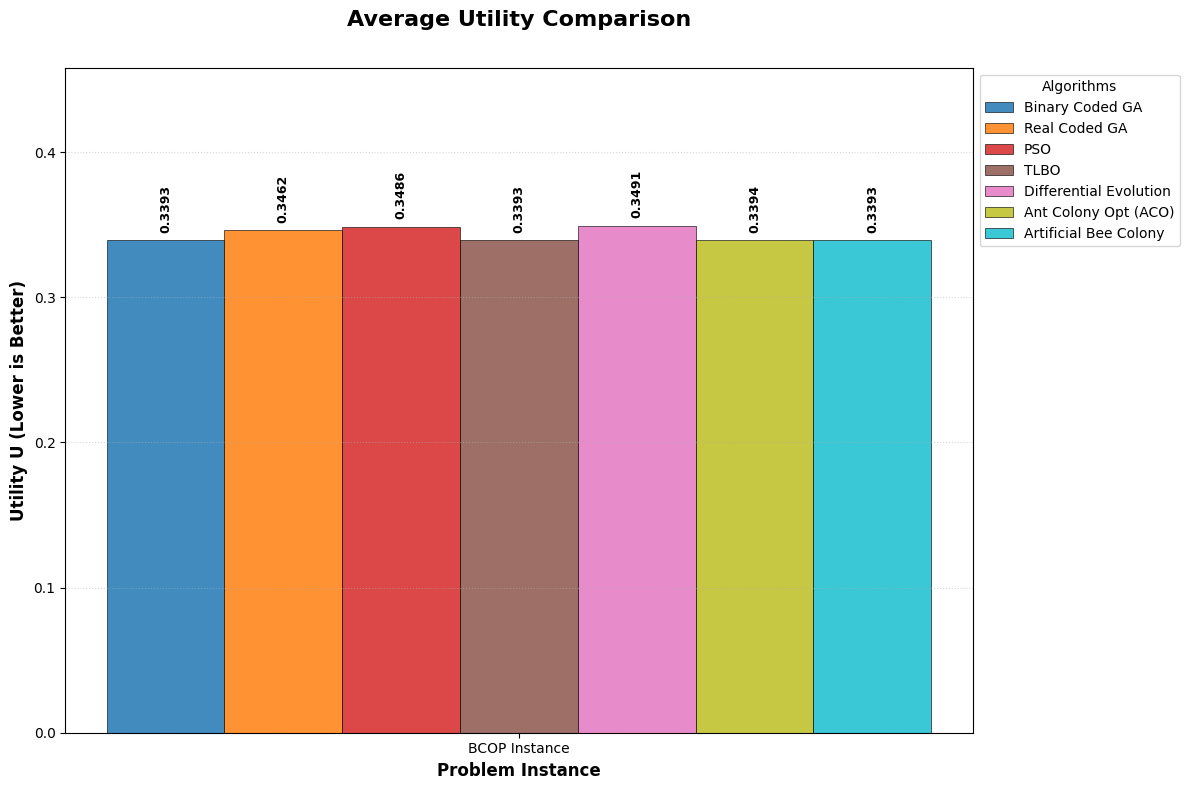

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


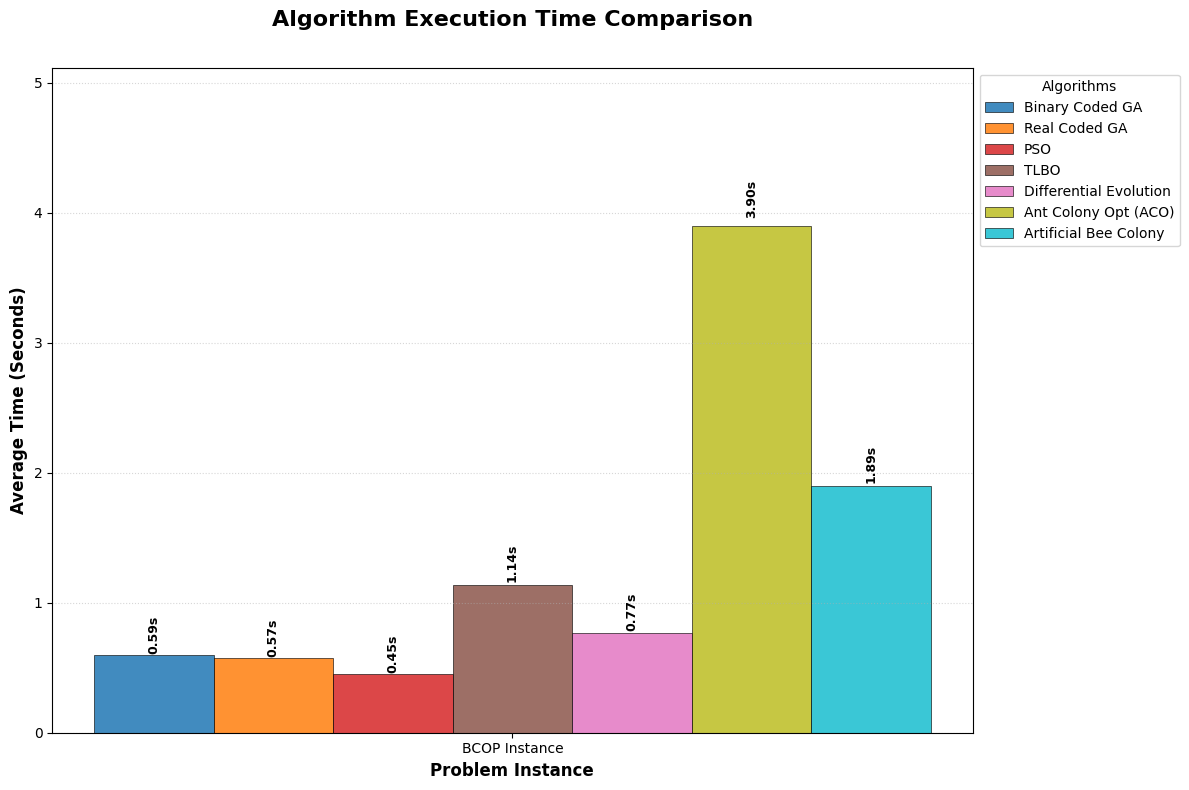

In [21]:
# ==========================================
# 4. Execute Simulation
# ==========================================
validators = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02,
              138.59, 207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89,
              121.47, 198.76, 254.19, 167.43, 289.05, 132.88]

run_bcop_experiment(validators)

--- Running BCOP Optimization Experiment (10 Iterations) ---

[Binary Coded GA - Run 1 Details] Validators Selected: 40 | Transactions: 50 | Utility: 0.3426
[Binary Coded GA - Overall] Avg Utility: 0.3426 | Best Utility: 0.3426 | Avg Time: 0.61s

[Real Coded GA - Run 1 Details] Validators Selected: 35 | Transactions: 50 | Utility: 0.3547
[Real Coded GA - Overall] Avg Utility: 0.3552 | Best Utility: 0.3474 | Avg Time: 0.53s

[PSO - Run 1 Details] Validators Selected: 37 | Transactions: 50 | Utility: 0.3471
[PSO - Overall] Avg Utility: 0.3504 | Best Utility: 0.3426 | Avg Time: 0.40s

[TLBO - Run 1 Details] Validators Selected: 40 | Transactions: 50 | Utility: 0.3426
[TLBO - Overall] Avg Utility: 0.3431 | Best Utility: 0.3426 | Avg Time: 1.16s

[Differential Evolution - Run 1 Details] Validators Selected: 35 | Transactions: 50 | Utility: 0.3557
[Differential Evolution - Overall] Avg Utility: 0.3521 | Best Utility: 0.3456 | Avg Time: 0.86s

[Ant Colony Opt (ACO) - Run 1 Details] Validators

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


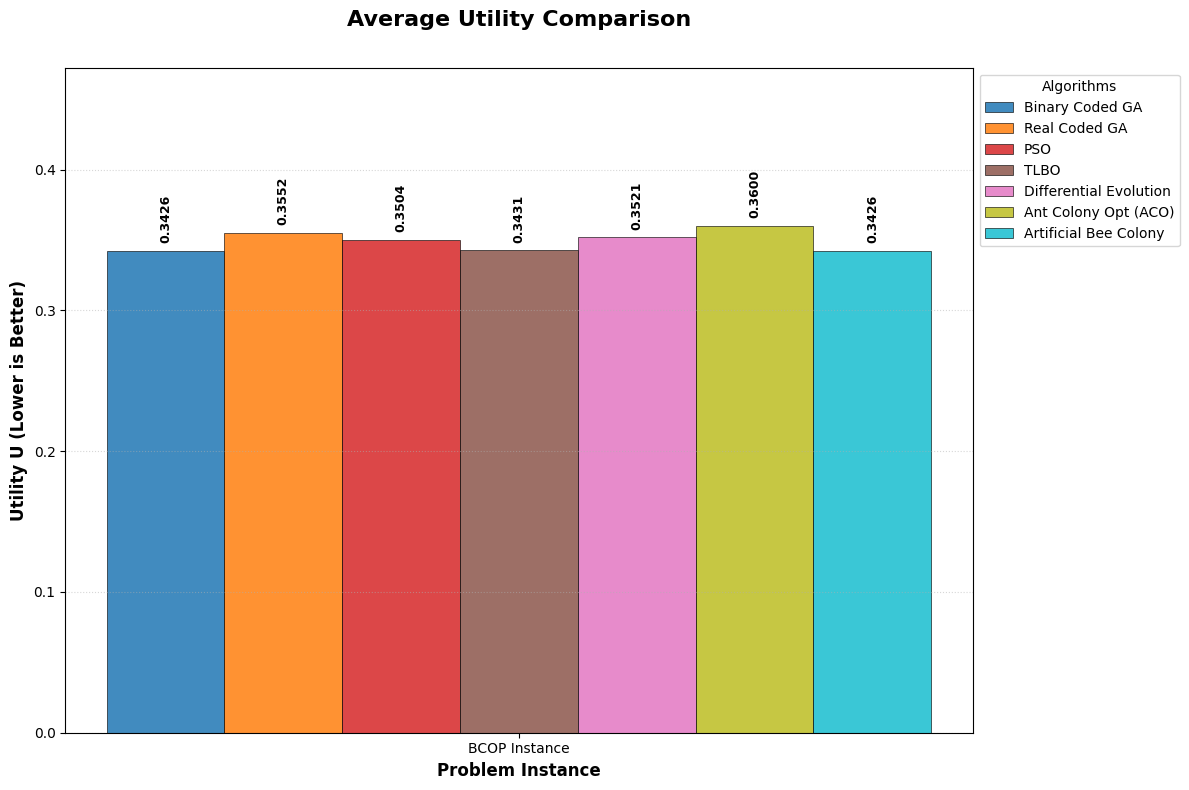

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


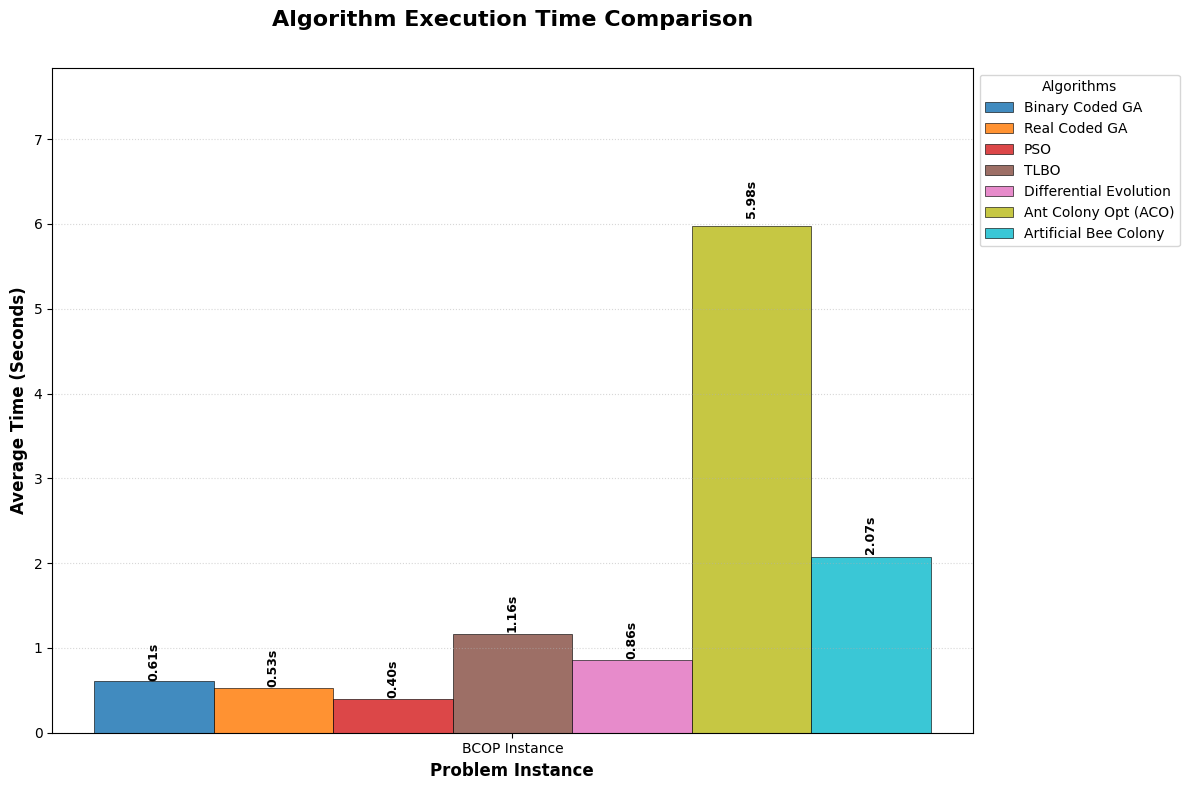

In [22]:
# ==========================================
# 4. Execute Simulation
# ==========================================
validators = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58,
255.98, 249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22,
153.01, 116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63,
115.13, 236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30,
104.61 ]

# Ek single run karenge deep generation setup ke sath curve dekhne ke liye
run_bcop_experiment(validators)

--- Running BCOP Optimization Experiment (10 Iterations) ---

[Binary Coded GA - Run 1 Details] Validators Selected: 60 | Transactions: 50 | Utility: 0.3457
[Binary Coded GA - Overall] Avg Utility: 0.3457 | Best Utility: 0.3457 | Avg Time: 0.63s

[Real Coded GA - Run 1 Details] Validators Selected: 49 | Transactions: 50 | Utility: 0.3595
[Real Coded GA - Overall] Avg Utility: 0.3591 | Best Utility: 0.3545 | Avg Time: 0.54s

[PSO - Run 1 Details] Validators Selected: 53 | Transactions: 50 | Utility: 0.3544
[PSO - Overall] Avg Utility: 0.3534 | Best Utility: 0.3497 | Avg Time: 0.42s

[TLBO - Run 1 Details] Validators Selected: 58 | Transactions: 50 | Utility: 0.3470
[TLBO - Overall] Avg Utility: 0.3467 | Best Utility: 0.3457 | Avg Time: 1.14s

[Differential Evolution - Run 1 Details] Validators Selected: 53 | Transactions: 50 | Utility: 0.3531
[Differential Evolution - Overall] Avg Utility: 0.3563 | Best Utility: 0.3526 | Avg Time: 0.89s

[Ant Colony Opt (ACO) - Run 1 Details] Validators

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


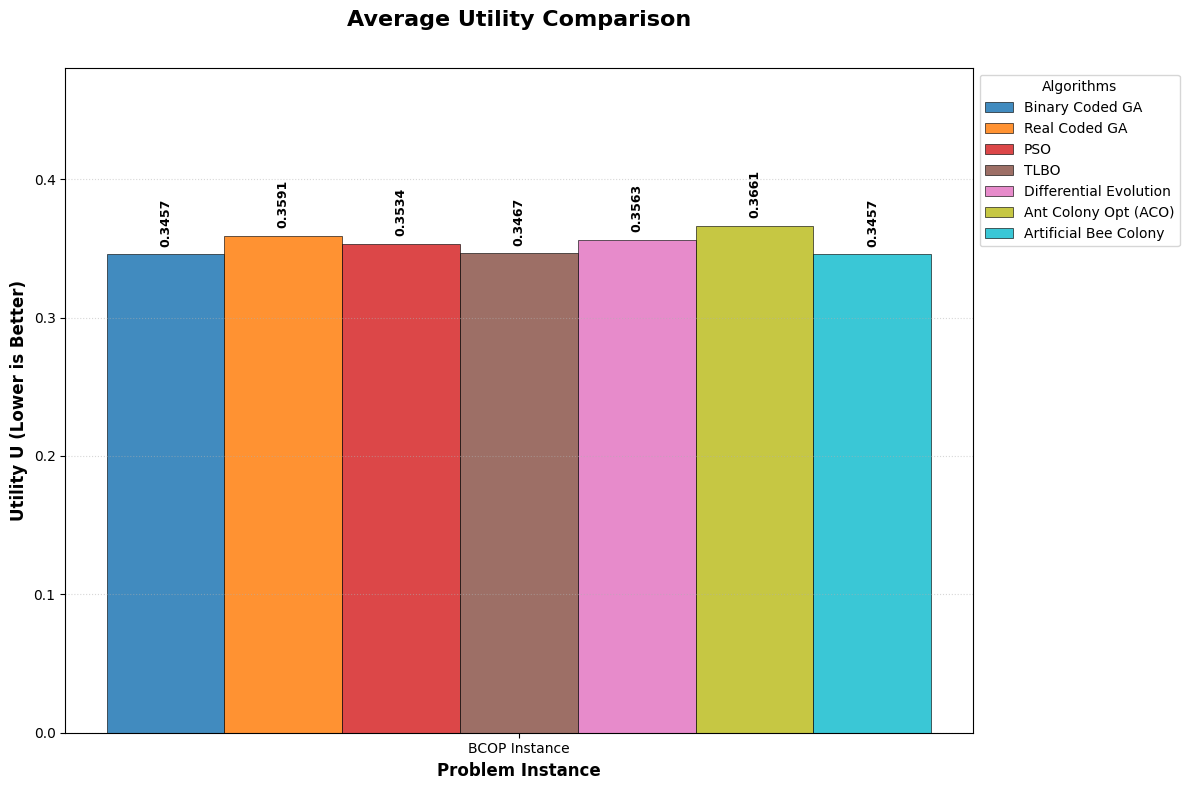

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


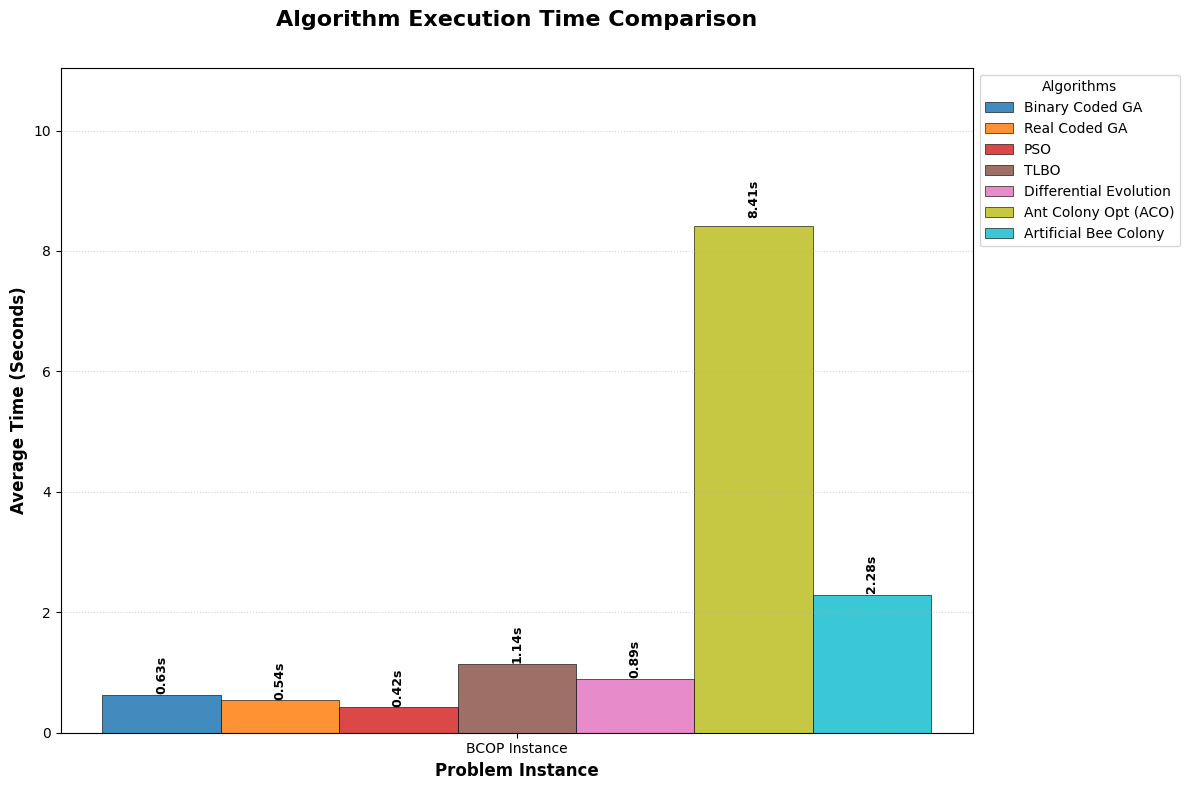

In [23]:
validators = [
    174.91, 290.14, 246.40, 219.73, 131.20, 131.19, 111.62, 273.23, 220.22, 241.61,
    104.12, 293.98, 266.49, 142.47, 136.36, 136.68, 160.92, 204.91, 186.38, 158.24,
    222.37, 127.89, 158.43, 191.24, 190.22, 116.15, 202.85, 219.26, 218.42, 109.29,
    158.42, 113.01, 118.97, 289.43, 293.10, 261.73, 160.91, 118.04, 236.98, 188.05,
    124.41, 106.90, 281.33, 101.40, 113.00, 100.10, 273.05, 142.04, 209.64, 113.37,
    161.47, 134.42, 100.17, 283.31, 290.62, 174.05, 158.55, 231.81, 139.11, 248.65
]

run_bcop_experiment(validators)

--- Running BCOP Optimization Experiment (10 Iterations) ---

[Binary Coded GA - Run 1 Details] Validators Selected: 79 | Transactions: 50 | Utility: 0.3487
[Binary Coded GA - Overall] Avg Utility: 0.3484 | Best Utility: 0.3484 | Avg Time: 0.60s

[Real Coded GA - Run 1 Details] Validators Selected: 68 | Transactions: 50 | Utility: 0.3553
[Real Coded GA - Overall] Avg Utility: 0.3590 | Best Utility: 0.3553 | Avg Time: 0.64s

[PSO - Run 1 Details] Validators Selected: 67 | Transactions: 50 | Utility: 0.3554
[PSO - Overall] Avg Utility: 0.3551 | Best Utility: 0.3526 | Avg Time: 0.52s

[TLBO - Run 1 Details] Validators Selected: 74 | Transactions: 50 | Utility: 0.3510
[TLBO - Overall] Avg Utility: 0.3501 | Best Utility: 0.3487 | Avg Time: 1.34s

[Differential Evolution - Run 1 Details] Validators Selected: 61 | Transactions: 50 | Utility: 0.3590
[Differential Evolution - Overall] Avg Utility: 0.3579 | Best Utility: 0.3563 | Avg Time: 0.95s

[Ant Colony Opt (ACO) - Run 1 Details] Validators

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


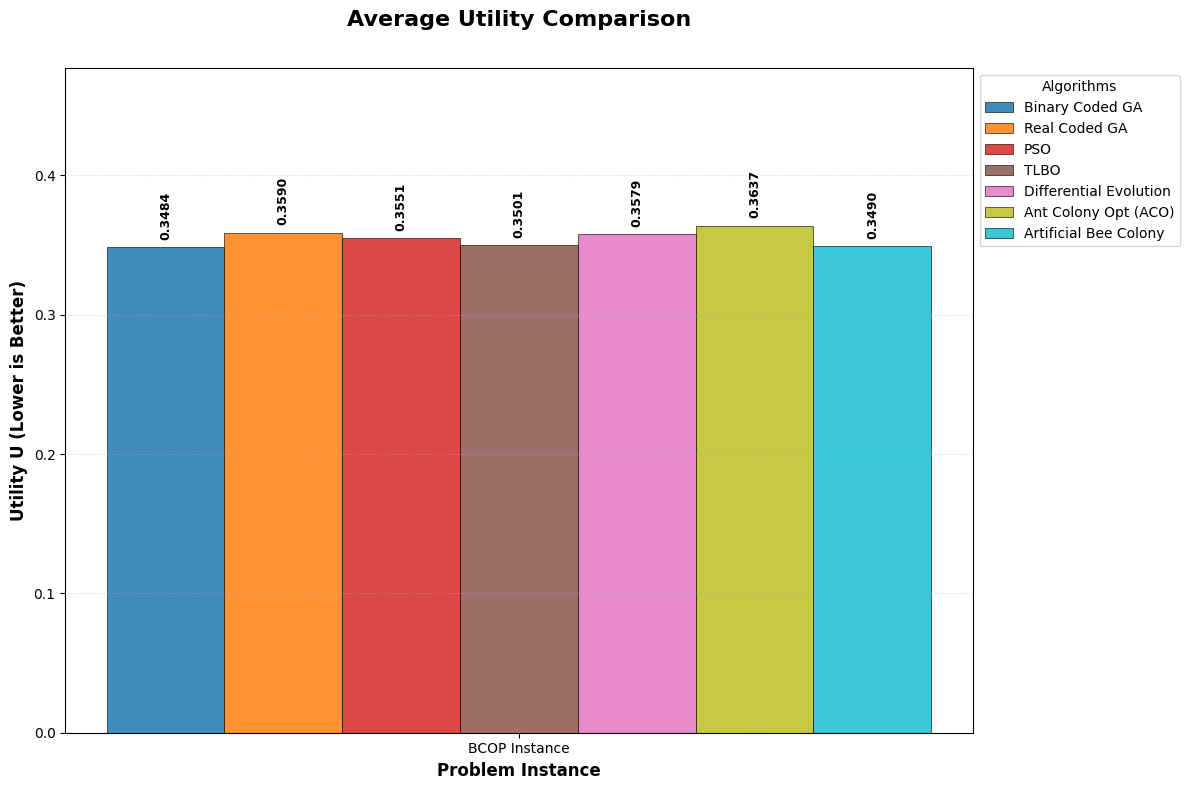

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


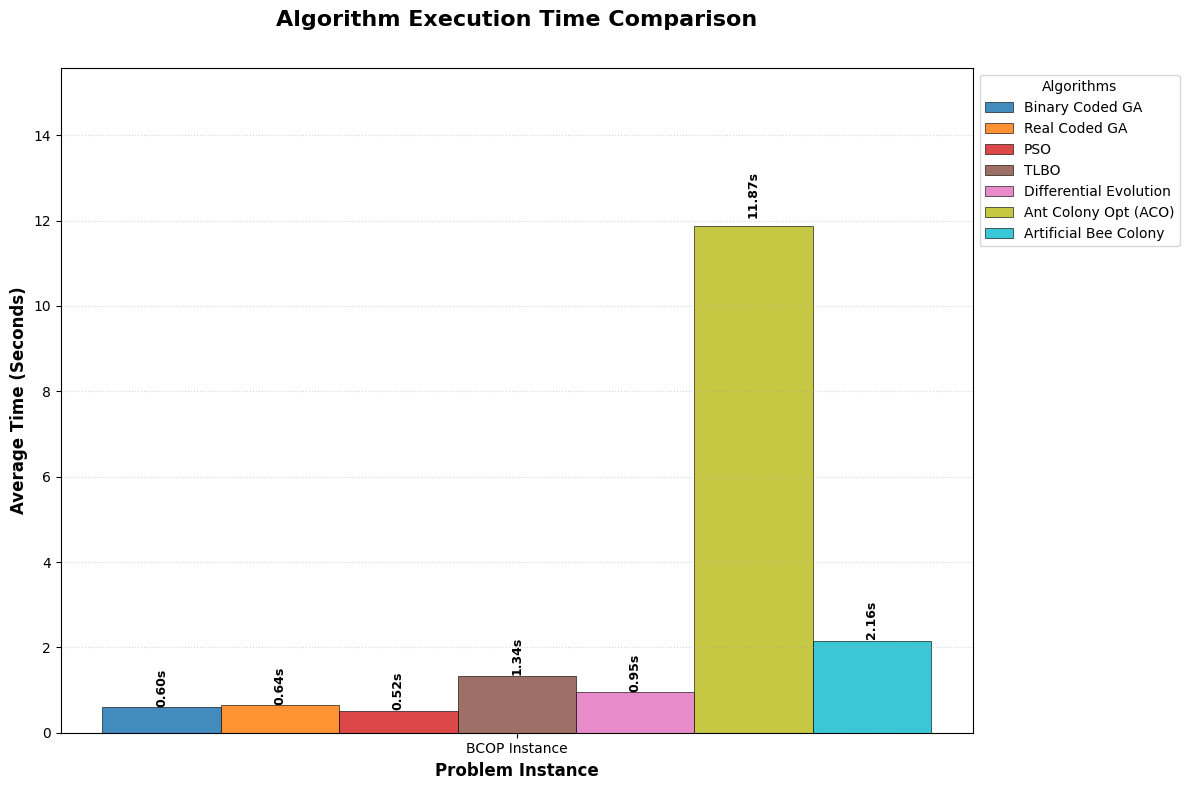

In [24]:
validators = [
    177.74, 154.27, 265.75, 171.35, 156.19, 103.58, 269.83, 140.23, 276.10, 192.36,
    275.60, 115.65, 295.66, 242.06, 127.42, 112.56, 115.11, 249.20, 246.33, 243.68,
    229.07, 150.91, 110.15, 275.98, 151.05, 128.79, 169.57, 151.01, 149.33, 240.24,
    188.16, 247.96, 146.47, 255.45, 117.72, 191.07, 287.89, 211.53, 138.81, 268.04,
    109.11, 122.95, 171.13, 284.14, 258.91, 180.70, 109.68, 133.00, 240.16, 113.43,
    104.93, 226.78, 145.41, 248.33, 170.83, 265.55, 123.63, 221.72, 176.60, 162.83,
    203.24, 240.35, 205.80, 242.54, 227.17, 202.93, 117.20, 181.72, 121.78, 199.53,
    223.77, 205.08, 113.62, 100.99, 134.11, 259.04, 276.51, 158.48, 107.03, 159.27
]

run_bcop_experiment(validators)

--- Running BCOP Optimization Experiment (10 Iterations) ---

[Binary Coded GA - Run 1 Details] Validators Selected: 98 | Transactions: 50 | Utility: 0.3517
[Binary Coded GA - Overall] Avg Utility: 0.3512 | Best Utility: 0.3512 | Avg Time: 0.70s

[Real Coded GA - Run 1 Details] Validators Selected: 71 | Transactions: 50 | Utility: 0.3663
[Real Coded GA - Overall] Avg Utility: 0.3636 | Best Utility: 0.3611 | Avg Time: 0.64s

[PSO - Run 1 Details] Validators Selected: 80 | Transactions: 50 | Utility: 0.3592
[PSO - Overall] Avg Utility: 0.3604 | Best Utility: 0.3575 | Avg Time: 0.47s

[TLBO - Run 1 Details] Validators Selected: 96 | Transactions: 50 | Utility: 0.3530
[TLBO - Overall] Avg Utility: 0.3523 | Best Utility: 0.3512 | Avg Time: 1.39s

[Differential Evolution - Run 1 Details] Validators Selected: 81 | Transactions: 50 | Utility: 0.3586
[Differential Evolution - Overall] Avg Utility: 0.3583 | Best Utility: 0.3559 | Avg Time: 0.90s

[Ant Colony Opt (ACO) - Run 1 Details] Validators

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


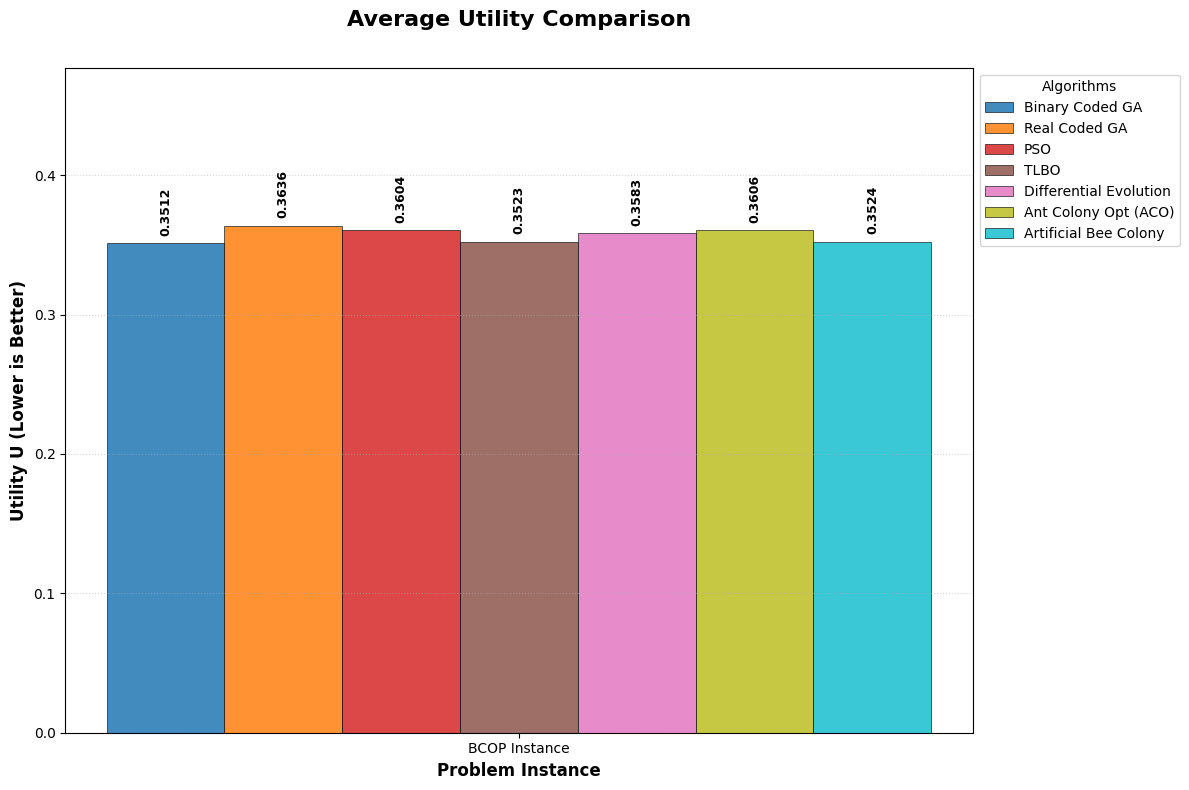

C:\Users\Harshit Katiyar\AppData\Local\Temp\ipykernel_5348\783051812.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_algos).colors


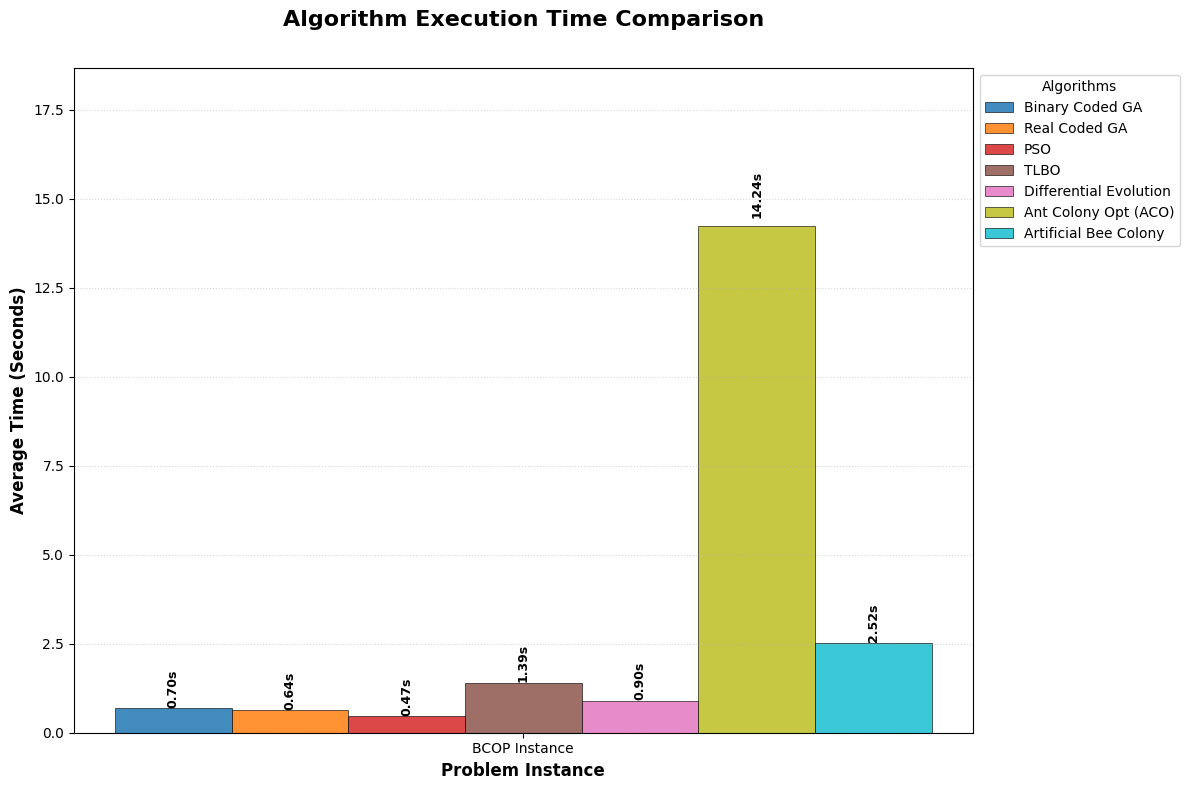

In [25]:
validators = [
    292.49, 150.36, 199.45, 160.18, 156.97, 181.02, 105.10, 247.51, 208.76, 244.31,
    278.43, 280.95, 266.38, 256.71, 122.18, 159.98, 236.42, 237.93, 137.49, 170.36,
    132.89, 221.11, 250.77, 290.47, 164.71, 202.66, 173.20, 294.67, 211.19, 156.12,
    258.98, 175.76, 232.08, 196.24, 225.10, 179.91, 103.79, 153.25, 248.86, 210.05,
    173.34, 190.10, 293.43, 160.03, 242.13, 208.41, 141.07, 124.64, 185.76, 226.79,
    109.11, 110.22, 143.06, 113.64, 241.07, 239.53, 131.02, 217.47, 132.50, 172.93,
    223.36, 142.00, 220.15, 120.73, 241.61, 274.57, 145.71, 280.12, 165.75, 293.07,
    106.88, 183.02, 187.97, 114.71, 212.16, 215.17, 118.80, 267.89, 121.23, 202.34,
    142.17, 150.36, 283.33, 178.69, 179.52, 256.40, 143.43, 150.05, 147.16, 297.05,
    203.35, 111.44, 174.91, 124.97, 231.29, 264.48, 102.67, 107.03, 136.98, 159.69
]

run_bcop_experiment(validators)